# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

O plano de solução consiste em realizar a leitura adequada dos arquivos, com o uso de parâmetros especifícos caso necessário seja.

In [1]:
# Importe as bibliotecas
import pandas as pd

In [3]:
# leia os conjuntos de dados em DataFrames
df_instacart_orders = pd.read_csv('..\datasets\instacart_orders.csv', sep=';')
df_products = pd.read_csv('..\datasets\products.csv', sep=';')
df_order_products = pd.read_csv('..\datasets\order_products.csv', sep=';')
df_aisles = pd.read_csv('..\\datasets\\aisles.csv', sep=';')
df_departaments = pd.read_csv('..\datasets\departments.csv', sep=';')

In [4]:
# imprima as informações sobre o DataFrame
df_instacart_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [5]:
# imprima as informações sobre o DataFrame
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49694 non-null  int64
 1   product_name   48436 non-null  str  
 2   aisle_id       49694 non-null  int64
 3   department_id  49694 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [6]:
# imprima as informações sobre o DataFrame
df_order_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [7]:
# imprima as informações sobre o DataFrame
df_aisles.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   aisle_id  134 non-null    int64
 1   aisle     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.2 KB


In [8]:
# imprima as informações sobre o DataFrame
df_departaments.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


## Conclusões


A leitura de arquivos obteve êxito com a ajuda do parâmetro "sep" pois os arquivos não estavam separados por "," como o habitual, mas com ";".
Foi identificada a necessidade de transformações, pois há valores ausentes.


# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

O plano de solução consiste em usar os métodos aprendidos para reconhecer dados nulos e/ou duplicados, e aplicar a devida correção.

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [9]:
# Verificar se há pedidos duplicados
print(f'Quantidade de elementos duplicados: {df_instacart_orders.duplicated().sum()}')
df_instacart_orders[df_instacart_orders.duplicated()]

Quantidade de elementos duplicados: 15


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


Há um total de 15 linhas duplicadas. Os elementos em comum são: pedidos feitos na mesma hora e no mesmo dia da semana.

In [10]:
# Com base nas suas conclusões, verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras
print(df_instacart_orders[(df_instacart_orders['order_dow'] == 3) & (df_instacart_orders['order_hour_of_day'] == 2)])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

O resultado quer dizer que cerca de 10% dos pedidos realizados na quarta-feira às 2h foram registrados como duplicatas.

In [11]:
# Remova pedidos duplicados
df_instacart_orders = df_instacart_orders.drop_duplicates()

In [12]:
# Verifique as linhas duplicadas mais uma vez
print(df_instacart_orders.duplicated().sum())
df_instacart_orders[df_instacart_orders.duplicated()]

0


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


In [13]:
# Verifique novamente apenas os IDs de pedidos duplicados
print(df_instacart_orders['order_id'].duplicated().sum())
df_instacart_orders[df_instacart_orders.duplicated()]

0


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


Todos os pedidos 100% duplicados estavam concentrados num ponto especifíco do tempo. Isso leva a crer que pode ter acontecido uma anomalia sistêmica naquela hora.

### DataFrame `products`


In [14]:
# Verifique se há linhas completamente duplicadas
print(f'Quantidade de linhas duplicadas: {df_products.duplicated().sum()}')
df_products[df_products.duplicated()]

Quantidade de linhas duplicadas: 0


,product_id,product_name,aisle_id,department_id


In [15]:
# Verifique apenas IDs dos produtos duplicados
print(f'Quantidade de IDs duplicados: {df_products.duplicated(subset="product_id").sum()}')
df_products[df_products.duplicated(subset='product_id')]

Quantidade de IDs duplicados: 0


,product_id,product_name,aisle_id,department_id


In [16]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)
print(f'Quantidade de nomes duplicados sem lower(): {df_products.duplicated(subset="product_name").sum()}')
name_low = df_products['product_name'].str.lower()
print(f'Quantidade de nomes duplicados com lower(): {name_low.duplicated().sum()}')
name_low[name_low.duplicated()]

Quantidade de nomes duplicados sem lower(): 1257
Quantidade de nomes duplicados com lower(): 1361


71                                                   NaN
109                                                  NaN
296                                                  NaN
416                                                  NaN
436                                                  NaN
                              ...                       
49689                      high performance energy drink
49690                      original pancake & waffle mix
49691    organic instant oatmeal light maple brown sugar
49692                             spring water body wash
49693                            burrito- steak & cheese
Name: product_name, Length: 1361, dtype: str

In [17]:
# Verifique os nomes de produtos duplicados que não estão faltando
name_low = name_low.dropna()
print(f'Quantidade de IDs duplicados: {name_low.duplicated().sum()}')
name_low[name_low.duplicated()]

Quantidade de IDs duplicados: 104


2058                                     biotin 1000 mcg
5455                    green tea with ginseng and honey
5558                              cream of mushroom soup
7558                           cinnamon rolls with icing
9037                              american cheese slices
                              ...                       
49689                      high performance energy drink
49690                      original pancake & waffle mix
49691    organic instant oatmeal light maple brown sugar
49692                             spring water body wash
49693                            burrito- steak & cheese
Name: product_name, Length: 104, dtype: str

Os dados foram separados num outro objeto para que pudesse realizar modificações: a eliminação dos itens em falta, e desta forma obter os resultados desejados.

### DataFrame `departments`

In [18]:
# Verifique se há linhas completamente duplicadas
print(f'Quantidade de linhas duplicadas: {df_departaments.duplicated().sum()}')

Quantidade de linhas duplicadas: 0


In [19]:
# Verifique apenas se há IDs dos produtos duplicados
print(f'Quantidade de IDs duplicados: {df_departaments.duplicated(subset="department_id").sum()}')

Quantidade de IDs duplicados: 0


Sem ocorrências neste DataFrame.

### DataFrame `aisles`

In [20]:
# Verifique se há linhas completamente duplicadas
print(f'Quantidade de linhas duplicadas: {df_aisles.duplicated().sum()}')

Quantidade de linhas duplicadas: 0


In [21]:
# Verifique apenas se há IDs dos produtos duplicados
print(f'Quantidade de IDs duplicados: {df_aisles.duplicated(subset="aisle_id").sum()}')

Quantidade de IDs duplicados: 0


Sem ocorrências neste DataFrame.

### DataFrame `order_products`

In [22]:
# Verifique se há linhas completamente duplicadas
print(f'A quantidade de linhas duplicadas é: {df_order_products.duplicated().sum()}')

A quantidade de linhas duplicadas é: 0


In [23]:
# Verifique mais uma vez se há outros casos complicados de duplicados
print(f'A quantidade de linhas com pedidos duplicados é: {df_order_products.duplicated(subset="order_id").sum()}')
print(f'A quantidade de linhas com produtos duplicados é: {df_order_products.duplicated(subset="product_id").sum()}')

A quantidade de linhas com pedidos duplicados é: 4094961
A quantidade de linhas com produtos duplicados é: 4499434


Sem ocorrências neste DataFrame, os valores duplicados acima são esperados pela dinâmica do DataFrame.

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [24]:
# Encontre valores ausentes na coluna 'product_name'
print(f'Quantidade de valores ausentes na coluna product_name: {df_products["product_name"].isna().sum()}')
print()
df_products[df_products['product_name'].isna()]

Quantidade de valores ausentes na coluna product_name: 1258



,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Foram encontrados 1258 valores ausentes na coluna product_name, e com uma pequena vista de olhos pôde ser notada uma simetria entre as colunas aisle_id e department_id.

In [25]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?
df_teste = df_products[df_products['product_name'].isna()]
df_teste['aisle_id'].value_counts()

aisle_id
100    1258
Name: count, dtype: int64

Todos os nomes de produtos ausentes estão associados com o corredor de ID 100.

In [26]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?
df_teste = df_products[df_products['department_id'] == 21]
df_teste['department_id'].value_counts()

department_id
21    1258
Name: count, dtype: int64

Todos os nomes de produtos ausentes estão associados com o departamento de ID 21.

In [27]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.
print(df_departaments[df_departaments['department_id'] == 21])
print()
print(df_aisles[df_aisles['aisle_id'] == 100])

    department_id department
20             21    missing

    aisle_id    aisle
99       100  missing


Ambas informações sobre o corredor e o departamento encontram-se desaparecidas.

In [28]:
# Preencha nomes de produtos ausentes com 'Unknown'
df_products['product_name'] = df_products['product_name'].fillna('Unknown')

A escolha pelo preenchimento dos valores ausentes por um texto genérico se deve ao fato de que nem em outras tabelas foram encontradas informações que poderiam ajudar a preencher de modo preciso.

### DataFrame `orders`

In [29]:
# Encontre os valores ausentes
df_instacart_orders.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [30]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
df_teste = df_instacart_orders[df_instacart_orders['order_number'] > 1]
print(df_teste.isna().sum())

order_id                  0
user_id                   0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


Foram encontrados muitos valores ausentes, contudo se concentram numa condição especifíca: clientes que fazem o primeiro pedido, logo a coluna *days_since_prior_order* perde sua utilidade.

### DataFrame `order_products`

In [31]:
# Encontre os valores ausentes
df_order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [32]:
# Quais são os valores mínimo e máximo dessa coluna?
print(df_order_products['add_to_cart_order'].min())
print(df_order_products['add_to_cart_order'].max())

1.0
64.0


A grande maioria dos valores ausentes se concentram na coluna *add_to_cart_order*, com variação de 1 para 64.

In [33]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'
df_teste = df_order_products[df_order_products['add_to_cart_order'].isna()]
order_id_2 = df_teste['order_id'].unique()

In [34]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
df_teste = df_teste[df_teste['order_id'].isin(order_id_2)]
df_teste['order_id'].value_counts().sort_values()
# Agrupe os pedidos com dados ausentes por ID de pedido
df_teste.groupby('order_id')['add_to_cart_order'].count()
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem
df_teste.groupby('order_id')['product_id'].count().sort_values()

order_id
9310        1
747668      1
888470      1
2621907     1
2170451     1
           ..
1959075    34
171934     40
2136777    44
3308010    51
61355      63
Name: product_id, Length: 70, dtype: int64

Em nenhum dos 70 pedidos com dados ausentes foram registrados mais de 64 itens (máxima).

In [35]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
df_order_products['add_to_cart_order'] = df_order_products['add_to_cart_order'].fillna(999)
df_order_products['add_to_cart_order'] = df_order_products['add_to_cart_order'].astype(int)
df_order_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB


O método adotado para preenchimento do dado ausente foi o uso de um numeral genérico, logo que é inviável usar outras métricas como média e mediana para prenchimento desta variável quantitativa.

## Conclusões

A observação prévia dos dados fornecidos e sua devida limpeza é um procedimento importante para garantir que as análises feitas em sequência possuam dados de confiabilidade e integralidade superiores, resultando em informações mais precisas e objetiva.

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [36]:
df_instacart_orders['order_hour_of_day'].unique()

array([13, 12, 19, 20, 11,  8, 18, 15, 16,  9, 22, 10,  0, 14, 17,  1,  7,
        6,  2, 21,  3, 23,  5,  4])

In [37]:
df_instacart_orders['order_dow'].unique()

array([6, 5, 0, 4, 3, 1, 2])

Os valores nas colunas 'order_hour_of_day' e 'order_dow' fazem sentido.

### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

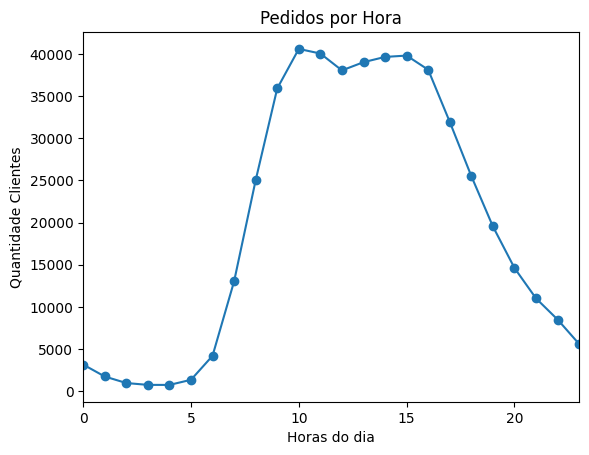

In [39]:
from matplotlib import pyplot as plt

grap_a2 = df_instacart_orders.groupby('order_hour_of_day')['user_id'].count().reset_index()

grap_a2.plot(
    title='Pedidos por Hora',
    x='order_hour_of_day',
    y='user_id',
    xlabel='Horas do dia',
    ylabel='Quantidade Clientes',
    xlim=[0,23],
    rot=360,
    style='-o',
    legend=False
)

plt.show()

As horas do dia com maior número de pedidos estão entre 9h-17h, enquanto as horas com menor número de pedidos estão entre as 2h-4h.

Minímo: 4h - 765

Máximo: 10h - 40578

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

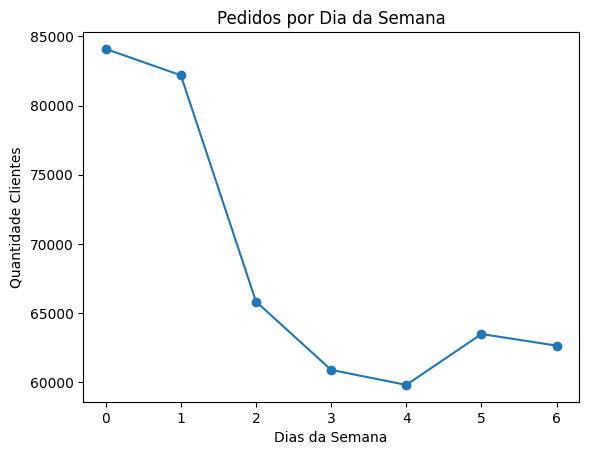

In [40]:
grap_a3 = df_instacart_orders.groupby('order_dow')['user_id'].count().reset_index()

grap_a3.plot(
  title='Pedidos por Dia da Semana',
  x='order_dow',
  y='user_id',
  xlabel='Dias da Semana',
  ylabel='Quantidade Clientes',
  rot=360,
  style='-o',
  legend=False
)

plt.show()


Os dias da semana com maior número de pedidos são o domingo e a segunda-feira, com os menores números são quarta e quinta-feira.

Máximo: 84090 - Domingo  

Mínimo: 59810 - Quinta-feira

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

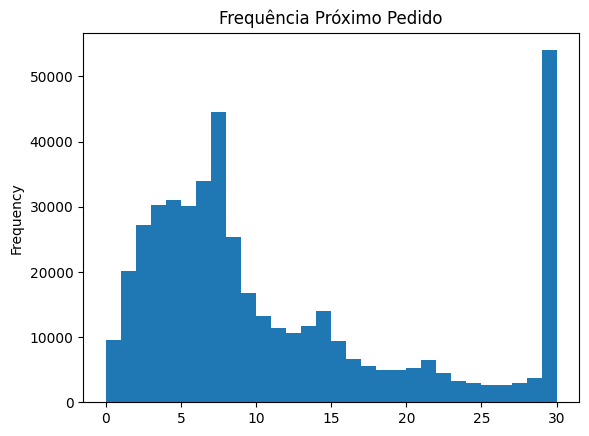

days_since_prior_order
30.0    51337
7.0     44577
6.0     33930
4.0     31006
3.0     30224
5.0     30096
2.0     27138
8.0     25361
1.0     20179
9.0     16753
14.0    13992
10.0    13309
13.0    11737
11.0    11467
12.0    10658
0.0      9589
15.0     9416
16.0     6587
21.0     6448
17.0     5498
20.0     5302
18.0     4971
19.0     4939
22.0     4514
28.0     3745
23.0     3337
24.0     3015
27.0     2986
25.0     2711
29.0     2673
26.0     2640
Name: count, dtype: int64

In [41]:
a4 = df_instacart_orders

a4['days_since_prior_order'].plot(kind='hist',
                                  title='Frequência Próximo Pedido',
                                  bins=30)
plt.show()

a4['days_since_prior_order'].value_counts()

A maior parte dos clientes leva cerca de 30 dias e 7 dias para um próximo pedido, o que pode indicar costume de compras mensais/semanais.

Máximo: 51337 - 30 dias

Minímo: 2640 - 26 dias

# [B] Médio (é necessário concluir tudo para passar)

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [42]:
b1_wed = df_instacart_orders[df_instacart_orders['order_dow'] == 3]

In [43]:
b1_sat = df_instacart_orders[df_instacart_orders['order_dow'] == 6]

In [44]:

b1_wed = b1_wed.groupby('order_hour_of_day')['order_id'].count()
b1_sat = b1_sat.groupby('order_hour_of_day')['order_id'].count()


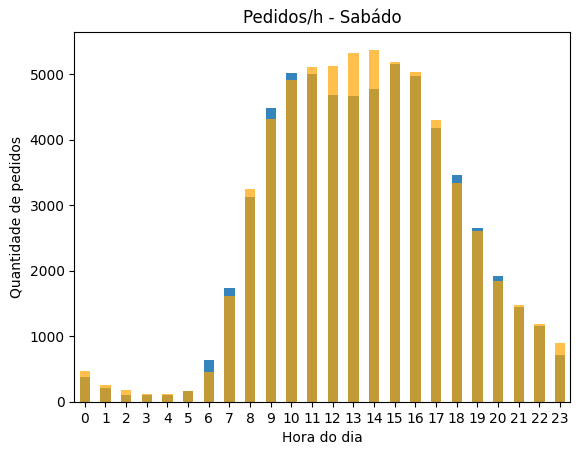

In [45]:
b1_wed.plot(
    title='Pedidos/h - Quarta-feira',
    kind='bar',
    rot=360,
    xlabel='Hora do dia',
    ylabel='Quantidade de pedidos',
    alpha=0.9
)
b1_sat.plot(
    title='Pedidos/h - Sabádo',
    xlabel='Hora do dia',
    ylabel='Quantidade de pedidos',
    kind='bar',
    rot=360,
    color='orange',
    alpha=0.7
)
plt.show()

Foram encontradas pequenas diferenças: Quarta foi mais concentrados no horário comercial.

Sábado foi mais distribuídos ao longo do dia, inclusive à noite.

### [B2] Qual é a distribuição do número de pedidos por cliente?

In [46]:
b2 = df_instacart_orders.groupby('order_number')['user_id'].count().reset_index()

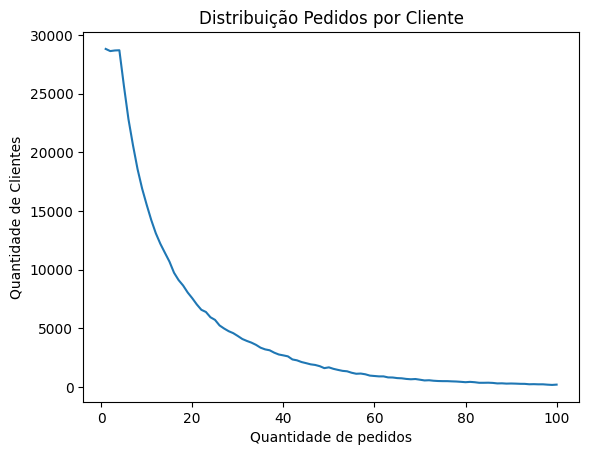

In [47]:
b2.plot(
    title='Distribuição Pedidos por Cliente',
    xlabel='Quantidade de pedidos',
    ylabel='Quantidade de Clientes',
    x='order_number',
    y='user_id',
    legend=False
    )

plt.show()

A taxa de fidelização dos clientes é muito baixa. É vista uma queda exponencial de clientes que não repetem pedidos ao longo do tempo.

Máximo - 28817 não passaram para um segundo pedido.

Mínimo - 169 clientes fizeram o pedido de número 99.

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [48]:
df_b3 = df_order_products.groupby('product_id')['order_id'].count().sort_values(ascending=False).reset_index()
df_b3 = df_b3.rename(columns={'order_id': 'orders_sum'})

In [49]:
df_b3_merged = df_b3.merge(df_products, on='product_id')
print(df_b3_merged)

       product_id  orders_sum  \
0           24852       66050   
1           13176       53297   
2           21137       37039   
3           21903       33971   
4           47209       29773   
...           ...         ...   
45568        5400           1   
45569        5398           1   
45570       44197           1   
45571       49663           1   
45572       49662           1   

                                            product_name  aisle_id  \
0                                                 Banana        24   
1                                 Bag of Organic Bananas        24   
2                                   Organic Strawberries        24   
3                                   Organic Baby Spinach       123   
4                                   Organic Hass Avocado        24   
...                                                  ...       ...   
45568                                     Coconut Flavor        17   
45569                                   Org

In [50]:
print(df_b3_merged[['product_id', 'product_name', 'orders_sum']].head(20))

    product_id              product_name  orders_sum
0        24852                    Banana       66050
1        13176    Bag of Organic Bananas       53297
2        21137      Organic Strawberries       37039
3        21903      Organic Baby Spinach       33971
4        47209      Organic Hass Avocado       29773
5        47766           Organic Avocado       24689
6        47626               Large Lemon       21495
7        16797              Strawberries       20018
8        26209                     Limes       19690
9        27845        Organic Whole Milk       19600
10       27966       Organic Raspberries       19197
11       22935      Organic Yellow Onion       15898
12       24964            Organic Garlic       15292
13       45007          Organic Zucchini       14584
14       39275       Organic Blueberries       13879
15       49683            Cucumber Kirby       13675
16       28204        Organic Fuji Apple       12544
17        5876             Organic Lemon      

O produto mais vendido é Banana, e fechando o top 20 com tomates cereja orgânicos.

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

In [51]:
c1 = df_order_products.groupby('order_id')['add_to_cart_order'].max().reset_index()

In [52]:
c1 = c1.groupby('add_to_cart_order')['order_id'].count().reset_index()
c1 = c1.rename(columns={'add_to_cart_order': 'sum_itens', 'order_id': 'order_count'})
c1 = c1.drop(64)
print(c1)

    sum_itens  order_count
0           1        21847
1           2        26292
2           3        29046
3           4        31054
4           5        31923
..        ...          ...
59         60           13
60         61           16
61         62           11
62         63           12
63         64            5

[64 rows x 2 columns]


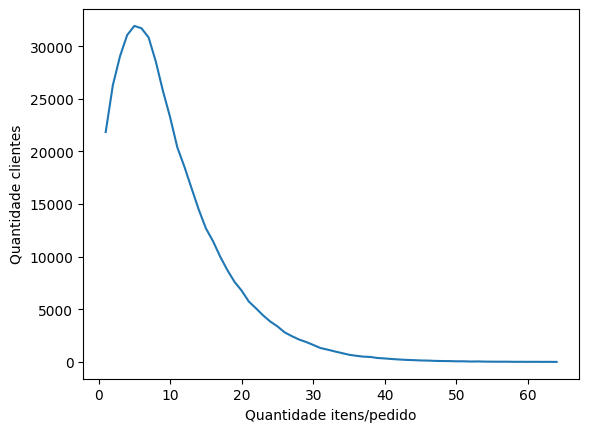

In [53]:
c1.plot(
    x='sum_itens',
    y='order_count',
    legend=False,
    xlabel='Quantidade itens/pedido',
    ylabel='Quantidade clientes',
)
plt.show()

A maior parte dos clientes fazem pedidos de cerca de 10 itens.

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [54]:
c2 = df_order_products[df_order_products['reordered'] == 1]
print(c2)

         order_id  product_id  add_to_cart_order  reordered
1          567889        1560                  1          1
2         2261212       26683                  1          1
3          491251        8670                 35          1
4         2571142        1940                  5          1
5         2456893       21616                  4          1
...           ...         ...                ...        ...
4544999   1622300       24852                  1          1
4545000   1125324       40600                  6          1
4545002    577211       15290                 12          1
4545004    692640       47766                  4          1
4545005    319435         691                  8          1

[2683838 rows x 4 columns]


In [55]:
c2 = c2.groupby('product_id')['order_id'].count().sort_values(ascending=False).reset_index()
c2 = c2.rename(columns={'order_id': 'sum_orders'})
print(c2)

       product_id  sum_orders
0           24852       55763
1           13176       44450
2           21137       28639
3           21903       26233
4           47209       23629
...           ...         ...
36223       41219           1
36224       41253           1
36225       41252           1
36226       41284           1
36227       41281           1

[36228 rows x 2 columns]


In [56]:
c2_merge = c2.merge(df_products, on='product_id')

In [57]:
print(c2_merge[['product_id', 'product_name', 'sum_orders']].head(20))

    product_id              product_name  sum_orders
0        24852                    Banana       55763
1        13176    Bag of Organic Bananas       44450
2        21137      Organic Strawberries       28639
3        21903      Organic Baby Spinach       26233
4        47209      Organic Hass Avocado       23629
5        47766           Organic Avocado       18743
6        27845        Organic Whole Milk       16251
7        47626               Large Lemon       15044
8        27966       Organic Raspberries       14748
9        16797              Strawberries       13945
10       26209                     Limes       13327
11       22935      Organic Yellow Onion       11145
12       24964            Organic Garlic       10411
13       45007          Organic Zucchini       10076
14       49683            Cucumber Kirby        9538
15       28204        Organic Fuji Apple        8989
16        8277  Apple Honeycrisp Organic        8836
17       39275       Organic Blueberries      

O item mais incluído em pedidos repetidos é a Banana, e fechando o top20 temos meio a meio orgânico.

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [58]:
c3 = df_order_products.groupby('product_id')['order_id'].count().reset_index()
print(c3)
c3_2 = df_order_products.groupby('product_id')['reordered'].sum().reset_index()
print(c3_2)

       product_id  order_id
0               1       280
1               2        11
2               3        42
3               4        49
4               7         2
...           ...       ...
45568       49690         5
45569       49691        72
45570       49692        12
45571       49693        25
45572       49694         9

[45573 rows x 2 columns]


       product_id  reordered
0               1        158
1               2          0
2               3         31
3               4         25
4               7          1
...           ...        ...
45568       49690          4
45569       49691         31
45570       49692          5
45571       49693         11
45572       49694          3

[45573 rows x 2 columns]


In [59]:
c3_merged = c3.merge(c3_2, on='product_id')
c3_merged = c3_merged.merge(df_products, on='product_id')
c3_merged = c3_merged.drop(["aisle_id", "department_id"], axis=1)
print(c3_merged)

       product_id  order_id  reordered  \
0               1       280        158   
1               2        11          0   
2               3        42         31   
3               4        49         25   
4               7         2          1   
...           ...       ...        ...   
45568       49690         5          4   
45569       49691        72         31   
45570       49692        12          5   
45571       49693        25         11   
45572       49694         9          3   

                                            product_name  
0                             Chocolate Sandwich Cookies  
1                                       All-Seasons Salt  
2                   Robust Golden Unsweetened Oolong Tea  
3      Smart Ones Classic Favorites Mini Rigatoni Wit...  
4                         Pure Coconut Water With Orange  
...                                                  ...  
45568                      HIGH PERFORMANCE ENERGY DRINK  
45569                  

In [60]:
c3_merged['proportion'] = c3_merged['reordered'] / c3_merged['order_id']
print(c3_merged[['product_id', 'product_name', 'proportion']])
print(c3_merged[c3_merged['proportion'] == 1])
print(c3_merged[c3_merged['proportion'] == 0])

       product_id                                       product_name  \
0               1                         Chocolate Sandwich Cookies   
1               2                                   All-Seasons Salt   
2               3               Robust Golden Unsweetened Oolong Tea   
3               4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4               7                     Pure Coconut Water With Orange   
...           ...                                                ...   
45568       49690                      HIGH PERFORMANCE ENERGY DRINK   
45569       49691                      ORIGINAL PANCAKE & WAFFLE MIX   
45570       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR   
45571       49693                             SPRING WATER BODY WASH   
45572       49694                            BURRITO- STEAK & CHEESE   

       proportion  
0        0.564286  
1        0.000000  
2        0.738095  
3        0.510204  
4        0.500000  
...           .

Há um total de 1809 produtos que sempre foram reordenados, enquanto há 9345 que nunca foram.


### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

Escreva suas conclusões aqui

### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [61]:
c5 = df_order_products[df_order_products['add_to_cart_order'] == 1]

In [62]:
c5 = c5.groupby('product_id')['order_id'].count().reset_index().sort_values(by='order_id', ascending=False)

In [63]:
c5_merged = c5.merge(df_products, on='product_id')
c5_merged = c5_merged.rename(columns={'order_id': 'sum_orders'})
print(c5_merged[['product_id', 'product_name', 'sum_orders']].head(20))

    product_id                 product_name  sum_orders
0        24852                       Banana       15562
1        13176       Bag of Organic Bananas       11026
2        27845           Organic Whole Milk        4363
3        21137         Organic Strawberries        3946
4        47209         Organic Hass Avocado        3390
5        21903         Organic Baby Spinach        3336
6        47766              Organic Avocado        3044
7        19660                 Spring Water        2336
8        16797                 Strawberries        2308
9        27966          Organic Raspberries        2024
10       44632   Sparkling Water Grapefruit        1914
11       49235          Organic Half & Half        1797
12       47626                  Large Lemon        1737
13         196                         Soda        1733
14       38689     Organic Reduced Fat Milk        1397
15       26209                        Limes        1370
16       12341                Hass Avocados     

Com uma grande liderança, o item mais vezes colocado no carrinho primeiro foram as Bananas, e fechando o top 20 com Framboesa.

# Conclusão geral do projeto: